In [1]:
# 🚀 Project — Customer Segmentation

# Using: K-Means Clustering

In [2]:
# 🎯 Goal

# Group customers into different segments based on behavior.

# 👉 Example output:

# High spenders
# Average customers
# Low spenders

In [3]:
# 🔷 Step 1 — Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
# 🔷 Step 2 — Load Dataset

# Use Mall Customer dataset (you can download from Kaggle or create sample).

In [9]:
df = pd.read_csv("data-sets/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
# 🔷 Step 3 — Select Features

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [18]:
# 🔷 Step 4 — Feature Scaling (Very Important)

# 👉 K-Means is distance-based
# 👉 Large values dominate otherwise

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

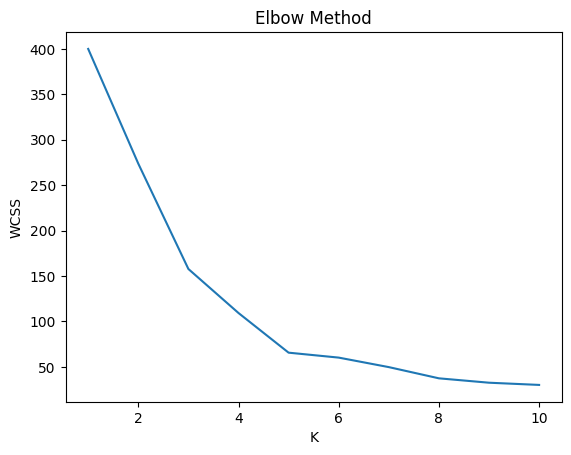

In [20]:
# 🔷 Step 5 — Find Optimal K (Elbow Method)

wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [21]:
# 👉 Suppose elbow is at:

# K = 5

In [22]:
# 🔷 Step 6 — Apply K-Means

model = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = model.fit_predict(X_scaled)

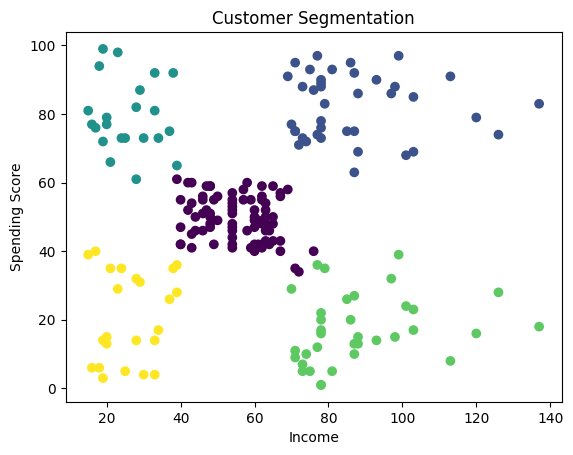

In [23]:
# 🔷 Step 7 — Visualize Clusters

plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
            c=df["Cluster"])

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [25]:
# 🔷 Step 8 — Understand Clusters

# Check cluster centers:

model.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [26]:
# Interpret:

# Cluster	Meaning
# Cluster 0	Low income, low spending
# Cluster 1	High income, high spending
# Cluster 2	High income, low spending
# Cluster 3	Low income, high spending
# Cluster 4	Medium customers

In [27]:
# Performed customer segmentation using K-Means clustering and identified distinct customer groups based on income and spending patterns.